In [ ]:
!pip install matplotlib numpy scipy

In [2]:
%load_ext autoreload
%autoreload 2

from scipy.constants import speed_of_light as SPEED_OF_LIGHT
import numpy as np
import importlib
import matplotlib.pyplot as plt
import matplotlib as mpl
from copy import copy
import sys
import os
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch

from simulation import *

import simulation

importlib.reload(simulation)

np.set_printoptions(threshold=sys.maxsize)

In [3]:
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": 8,

    # IEEE-like sizing
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.titlesize": 8,

    # Better PDF output
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

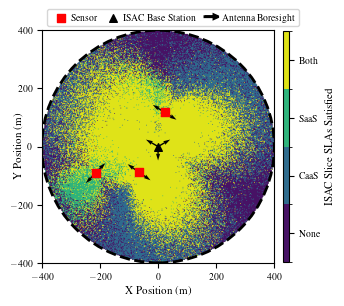

In [4]:
np.random.seed(59)

data = copy(SCENARIOS["mmWave"]["LOW_UE_LOW_TARGET"])
data["TARGET_SENSING_PRBS"] = (data["N_PRBS"]-data["UPLINK_PRBS"]) // 2
data["UE_SENSING_PRBS"] = data["TARGET_SENSING_PRBS"]
data["UE_COMM_PRBS"] = data["N_PRBS"] - data["UPLINK_PRBS"] - data["TARGET_SENSING_PRBS"]
data["FORCED_SLOT_ALLOCATION"] = data["SLOTS_PER_FRAME"] // 6
grid_size = 300
data = pos_targets_grid(data, grid_size=grid_size)
data = pos_sensors(data)

data = run_pre_allocation_and_assignment(data)
data = alloc_beams(data, method="forced_full")
data = alloc_bandwidth(data, method="forced")
data = run_pre_assignment(data)
data = assign_sensors(data)
data = run_post_assignment(data, no_sensor_demand_warning=True)


fig, ax = plt.subplots(figsize=(3.5, 3.7))
fig, ax = plot_isac_satisfaction_heatmap(
    data,
    fig=fig,
    ax=ax,
    realization=0,
    cmap="viridis",
    grid_size=grid_size,
    no_legend=True,
    icon_size=30,
    no_sensor_text=True
)

# Adding the antenna boresight direction marker
handles, labels = ax.get_legend_handles_labels()
def make_legend_arrow(
    legend,
    orig_handle,
    xdescent,
    ydescent,
    width,
    height,
    fontsize
):
    return FancyArrowPatch(
        (0, height / 2),
        (width, height / 2),
        arrowstyle='Simple,head_length=10,head_width=9,tail_width=1',
        mutation_scale=0.35,
        linewidth=1.3,
        color='white',
        joinstyle='miter',
        capstyle='butt'
    )
quiver_handle = FancyArrowPatch(
    (0, 0),
    (1, 0),
    arrowstyle='Simple,head_length=10,head_width=9,tail_width=1',
    mutation_scale=0.5,
    linewidth=1.7,
    color='black',
    joinstyle='miter',
    capstyle='butt'
)
handles.append(quiver_handle)
labels.append("Antenna Boresight")
fig.legend(
    handles,
    labels,
    ncols=3,
    loc="upper center",
    handler_map={
        FancyArrowPatch: HandlerPatch(
            patch_func=make_legend_arrow
        )
    },
    columnspacing=0.6,
    labelspacing=0.3,
    handletextpad=0.05,
    bbox_to_anchor=(0.5, 0.84),
)
fig.tight_layout(rect=[0, 0.03, 1, 0.88])
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/0_scenario.pdf", bbox_inches="tight")